In [ ]:
pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from collections import Counter
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN



In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fraud Detection Dataset.csv to Fraud Detection Dataset.csv


In [ ]:
df = pd.read_csv("Fraud Detection Dataset.csv")

In [ ]:
print(list(df.columns))

['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


# Partition

In [ ]:
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=42)
len(partition)

35700

# Random

In [ ]:
sample_random = df.sample(n=100)
sample_random.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
24924,T24925,4705,305.99,Bank Transfer,0.0,Tablet,Los Angeles,2,112,2,Invalid Method,0
42979,T42980,4172,3794.79,Bank Transfer,13.0,Mobile,Chicago,2,36,4,UPI,0
22745,T22746,1031,2457.92,Bill Payment,16.0,Tablet,Miami,0,118,6,UPI,0
1000,T1001,4322,3632.50,POS Payment,18.0,Tablet,Chicago,1,52,9,Debit Card,0
40780,T40781,2395,3729.27,Online Purchase,2.0,Tablet,Houston,0,53,10,UPI,0


# stratified

In [ ]:
sample_stratified = (
    df.groupby("Location")
      .apply(lambda x: x.sample(frac=0.1))
)
sample_stratified.head()
#sample_stratified.count()
#print(sample_stratified["Country"].value_counts())

/tmp/ipykernel_4897/2365512491.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.1))


Transaction_ID  User_ID  Transaction_Amount Transaction_Type  \
Location                                                                      
Boston   8328           T8329     3665             1843.35    Bank Transfer   
         36868         T36869     1929             3787.09   ATM Withdrawal   
         41669         T41670     3414             3986.86   ATM Withdrawal   
         13389         T13390     2646             4035.51  Online Purchase   
         11079         T11080     2025             3677.04      POS Payment   

                Time_of_Transaction Device_Used Location  \
Location                                                   
Boston   8328                  19.0     Desktop   Boston   
         36868                  1.0      Tablet   Boston   
         41669                 16.0     Desktop   Boston   
         13389                  NaN     Desktop   Boston   
         11079                 22.0     Desktop   Boston   

                Previous_Fraudulent_Transactions  Account_Age  \
Location                                                        
Boston   8328                                  1            1   
         36868                                 3           49   
         41669                                 2           97   
         13389                                 1           21   
         11079                                 0           79   

                Number_of_Transactions_Last_24H Payment_Method  Fraudulent  
Location                                                                    
Boston   8328                                 4    Credit Card           0  
         36868                               13     Debit Card           0  
         41669                                1    Credit Card           0  
         13389                               11    Credit Card           0  
         11079                               10     Debit Card           0

In [ ]:
sample_500 = df.sample(n=500, random_state=42)
print(sample_500.shape)
sample_500.head()

(500, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0


In [ ]:
# Location counts including missing values
location_counts = df['Location'].value_counts(dropna=False)
print(location_counts)

Location
Boston           6149
New York         6110
Seattle          6104
Chicago          6071
Houston          6031
Los Angeles      6012
Miami            5991
San Francisco    5985
NaN              2547
Name: count, dtype: int64


In [ ]:
# Drop rows where Location is NaN first
df_clean_loc = df.dropna(subset=['Location'])

# Determine target count per category (e.g., minimum group size or a set count like 5000)
min_count = df_clean_loc['Location'].value_counts().min()

# Sample min_count records per location
equalized_sample = (
    df_clean_loc
    .groupby('Location', group_keys=False)
    .apply(lambda x: x.sample(n=min_count, random_state=42))
)

print(equalized_sample['Location'].value_counts())

Location
Boston           5985
Chicago          5985
Houston          5985
Los Angeles      5985
Miami            5985
New York         5985
San Francisco    5985
Seattle          5985
Name: count, dtype: int64


/tmp/ipykernel_4897/731300883.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_count, random_state=42))


# Cluster

In [ ]:
countries = df["Location"].unique()
selected_countries = pd.Series(countries).sample(n=2, random_state=42)
sample_cluster = df[df["Location"].isin(selected_countries)]
sample_cluster.head(36)
#sample_cluster.count()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
20,T21,2685,973.51,Bill Payment,2.0,Mobile,New York,1,43,12,UPI,0
26,T27,3853,4065.44,Online Purchase,21.0,Tablet,New York,4,99,9,Net Banking,0
28,T29,2215,153.05,Bill Payment,20.0,Mobile,Los Angeles,3,82,2,Debit Card,0
29,T30,1955,705.98,Online Purchase,12.0,Mobile,Los Angeles,3,2,11,UPI,0
30,T31,3324,428.39,POS Payment,20.0,Desktop,New York,0,85,10,Credit Card,0
32,T33,1459,2212.25,Online Purchase,10.0,Desktop,New York,4,14,13,UPI,0
39,T40,1474,2411.20,Bank Transfer,19.0,Mobile,New York,4,14,12,NaN,0
40,T41,2082,2269.38,Online Purchase,8.0,Tablet,New York,0,51,1,Debit Card,0
45,T46,3747,4376.93,ATM Withdrawal,20.0,Mobile,New York,1,94,7,Net Banking,0


In [ ]:
# Top 5 and Bottom 5 locations
top_locations = df['Location'].value_counts().head(5).index
least_locations = df['Location'].value_counts().tail(5).index

# Filter dataset
sample_most_listed = df[df['Location'].isin(top_locations)]
sample_least_listed = df[df['Location'].isin(least_locations)]

print("Top locations count:\n", sample_most_listed['Location'].value_counts())
print("\nLeast locations count:\n", sample_least_listed['Location'].value_counts())

Top locations count:
 Location
Boston      6149
New York    6110
Seattle     6104
Chicago     6071
Houston     6031
Name: count, dtype: int64

Least locations count:
 Location
Chicago          6071
Houston          6031
Los Angeles      6012
Miami            5991
San Francisco    5985
Name: count, dtype: int64


In [ ]:
#Data Selection

In [ ]:
# 1. Missing Values
print("Missing values per column:\n", df.isnull().sum())

# 2. Identical (Unique / Zero-variance) Values Check
constant_columns = [col for col in df.columns if df[col].nunique() <= 1]
print("Columns with constant/identical values:", constant_columns)

# 3. Correlation Analysis (Numeric Features with Target)
corr = df.corr(numeric_only=True)
print("\nCorrelation with Fraudulent:\n", corr['Fraudulent'].sort_values(ascending=False))

# 4. Chi-Square Test (Categorical Features vs. Target)
from sklearn.feature_selection import chi2, SelectKBest

cat_cols = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
df_cat = df[cat_cols].fillna('Missing')

# Encode categorical variables for chi2 test
df_cat_encoded = pd.get_dummies(df_cat, drop_first=True)
y = df['Fraudulent']

chi_selector = SelectKBest(score_func=chi2, k='all')
chi_selector.fit(df_cat_encoded, y)

chi2_scores = pd.DataFrame({
    'Feature': df_cat_encoded.columns,
    'Chi2_Score': chi_selector.scores_,
    'p_value': chi_selector.pvalues_
}).sort_values(by='Chi2_Score', ascending=False)

print("\nChi-Square Test Results:\n", chi2_scores.head(10))

Missing values per column:
 Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64
Columns with constant/identical values: []

Correlation with Fraudulent:
 Fraudulent                          1.000000
User_ID                             0.008046
Time_of_Transaction                 0.007035
Account_Age                         0.006203
Transaction_Amount                  0.005507
Previous_Fraudulent_Transactions    0.001136
Number_of_Transactions_Last_24H    -0.003877
Name: Fraudulent, dtype: float64

Chi-Square Test Results:
                   

In [ ]:
# Correlation of all numerical features with the target variable 'Fraudulent'
corr = df.corr(numeric_only=True)
print(corr['Fraudulent'].sort_values(ascending=False))

Fraudulent                          1.000000
User_ID                             0.008046
Time_of_Transaction                 0.007035
Account_Age                         0.006203
Transaction_Amount                  0.005507
Previous_Fraudulent_Transactions    0.001136
Number_of_Transactions_Last_24H    -0.003877
Name: Fraudulent, dtype: float64


In [ ]:
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest

# Ensure X and Y are defined for the chi2 test
# df_cat_encoded and y were previously used successfully for chi2
X = df_cat_encoded
Y = y

selector = SelectKBest(score_func=chi2, k='all')

selector.fit(X, Y)

print(selector.scores_)

[2.86652384e-01 1.99875665e-02 1.56829325e+00 1.57616292e-01
 7.92825539e+00 1.92945198e+00 1.99784626e+00 1.25708755e-03
 4.36440414e+00 7.78233700e-01 7.08231662e-01 3.53681034e-02
 4.64291216e-02 4.01030346e-01 2.13301793e-02 4.14604115e+00
 1.41615270e-01 7.38888127e-02 2.36033239e+00 4.13246954e-05
 1.30799206e+00]


In [ ]:
X = df.drop('Fraudulent', axis=1)

Y = df['Fraudulent']

In [ ]:
#Split

Task 5:
ML Model

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
# 2. Simple Feature Engineering & Type Cleaning
# ---------------------------------------------------------
# Ratio of transaction amount relative to recent transaction burst
df["Amount_per_Txn"] = df["Transaction_Amount"] / (
    df["Number_of_Transactions_Last_24H"] + 1
)

# Indicator for late-night / off-peak hours (midnight to 5 AM)
df["Is_Night"] = (df["Time_of_Transaction"] <= 5).astype(int)

# Historical fraud frequency scaled by account age
df["Fraud_Rate"] = df["Previous_Fraudulent_Transactions"] / (
    df["Account_Age"] + 1
)

# Fix for TypeError: Ensure categorical columns are uniformly strings
cat_cols_to_fix = ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']
for col in cat_cols_to_fix:
    df[col] = df[col].astype(str).replace('nan', np.nan)

# Handle potential infinite values from divisions
df.replace([np.inf, -np.inf], 0, inplace=True)

In [ ]:
drop_cols = ["Transaction_ID", "User_ID", "Fraudulent"]
X = df.drop(columns=drop_cols)
y = df["Fraudulent"]

num_features = [
    "Transaction_Amount",
    "Time_of_Transaction",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H",
    "Amount_per_Txn",
    "Is_Night",
    "Fraud_Rate",
]

cat_features = [
    "Transaction_Type",
    "Device_Used",
    "Location",
    "Payment_Method",
]

for col in cat_features:
    X[col] = X[col].fillna("Missing").astype(str)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            cat_features,
        ),
    ]
)

In [ ]:
base_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42, class_weight="balanced_subsample", n_jobs=-1
            ),
        ),
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [ ]:
param_distributions = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [6, 12, 18, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", None],
}

tuned_search = RandomizedSearchCV(
    estimator=base_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("Starting Hyperparameter Tuning...")
# Ensure X and y are re-extracted from the cleaned df
X = df.drop(columns=drop_cols)
y = df["Fraudulent"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

tuned_search.fit(X_train, y_train)

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['Transaction_Amount',
                                                                                'Time_of_Transaction',
                                                                                'Previous_Fraudulent_Transactions',
                                                                                'Account_Age',
                                                                                'Number_of_Transactions_Last_24H',
                                                                                'Amount_per_Txn',
                                                                                'Is_Night'...
                                              RandomForestClassifier(class_weight='balanced_subsample',
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [6, 12, 18,
                                                                  None],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     None],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
# 8. Best Results
print("Best Hyperparameters:", tuned_search.best_params_)
print("Best Cross-Validation ROC-AUC:", round(tuned_search.best_score_, 4))

Best Hyperparameters: {'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}
Best Cross-Validation ROC-AUC: 0.5189



Test Set ROC-AUC: 0.5082

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       1.00      0.03      0.05       502

    accuracy                           0.95     10200
   macro avg       0.98      0.51      0.51     10200
weighted avg       0.95      0.95      0.93     10200



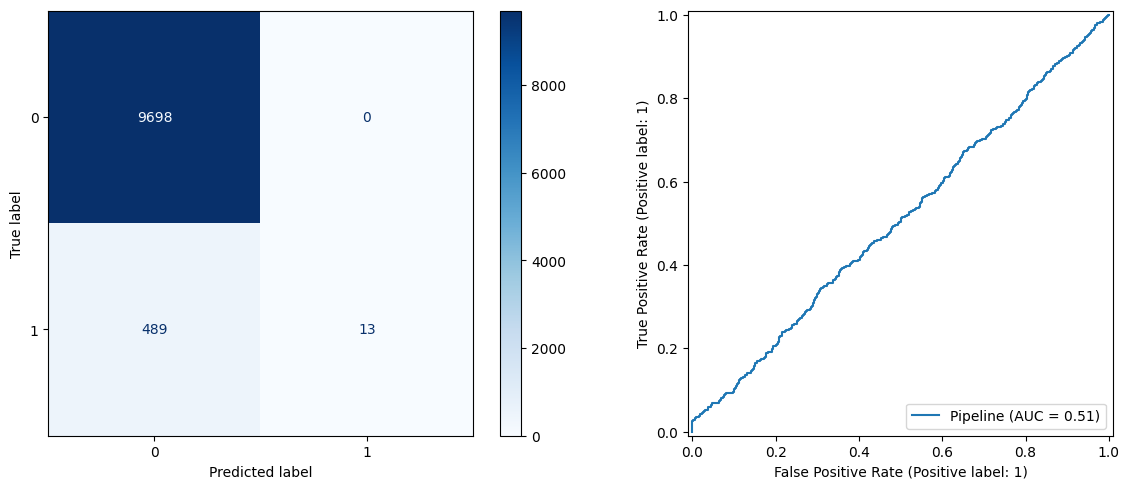

In [ ]:
# 9. Test Set Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt

best_model = tuned_search.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\nTest Set ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, ax=ax[0], cmap='Blues')
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax[1])
plt.tight_layout()
plt.show()

Result Analysis


NameError: name 'test_auc' is not defined

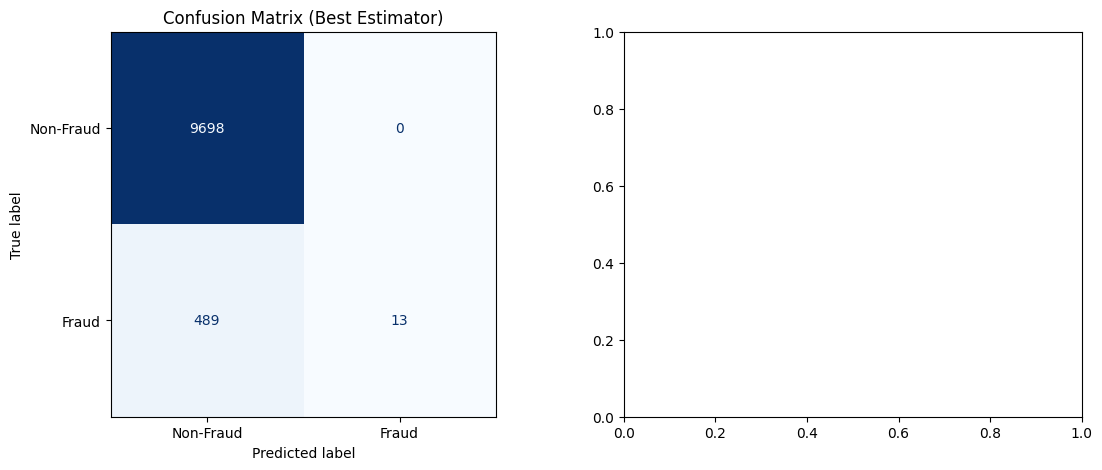

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-Fraud", "Fraud"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (Best Estimator)")
axes[0].grid(False)

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name=f"Tuned RF (AUC = {test_auc:.3f})",
    ax=axes[1],
    color="darkorange",
)
axes[1].plot([0, 1], [0, 1], "k--", label="Random Chance (AUC = 0.50)")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()